# Classical Statistical Generator — ARIMA-GARCH + Residual Bootstrap

Two-stage pipeline:
1. **ARIMA** captures the conditional mean (linear autocorrelation in returns).
2. **GARCH** captures the conditional variance of ARIMA residuals (volatility clustering).
3. **Residual Bootstrap** samples empirical standardised shocks to synthesise new series.

Model selection for both stages uses a **multi-metric composite** — not just AIC.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, scipy.stats as stats
import statsmodels.api as sm, warnings, os
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from arch import arch_model

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 11})
os.makedirs('outputs', exist_ok=True)
print('Setup complete.')

Setup complete.


In [2]:
train_df = pd.read_csv('../../data/processed/train.csv', parse_dates=['Date'], index_col='Date')
test_df  = pd.read_csv('../../data/processed/test.csv',  parse_dates=['Date'], index_col='Date')
y_train, y_test = train_df['Normalized'], test_df['Normalized']
N = len(y_train)
print(f'Train: {train_df.shape}   Test: {test_df.shape}')

Train: (5230, 3)   Test: (1308, 3)


## 1. Pre-Fit Diagnostics

| Plot | Purpose |
|------|---------|
| ACF/PACF of returns | Guides initial AR/MA order intuition |
| ACF of **squared** returns | Persistent bars => volatility clustering => GARCH needed |

**ADF Test** — H0: unit root (non-stationary). Reject if p < 0.05 or ADF stat < critical value.

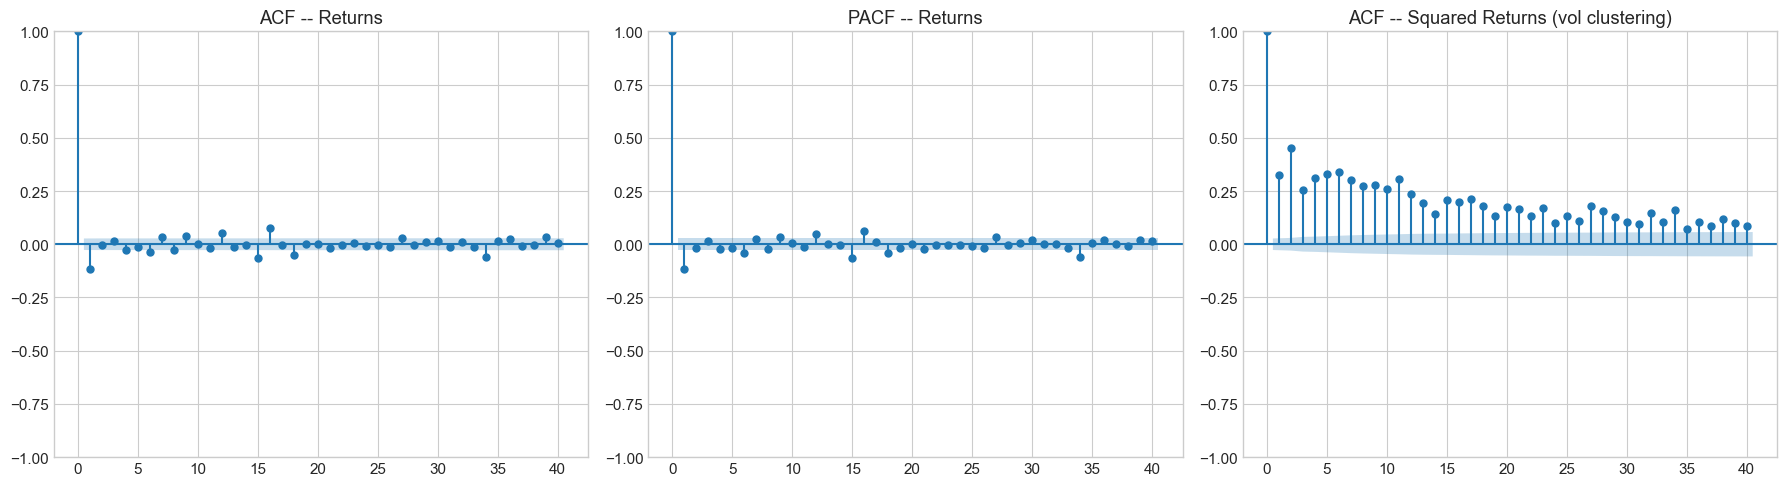

ADF stat=-13.4282  p=4.06e-25
  Critical 1%: -3.4316
  Critical 5%: -2.8621
  Critical 10%: -2.5671
=> STATIONARY -- d=0 justified


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_acf( y_train,    lags=40, ax=axes[0]); axes[0].set_title('ACF -- Returns')
plot_pacf(y_train,    lags=40, ax=axes[1]); axes[1].set_title('PACF -- Returns')
plot_acf( y_train**2, lags=40, ax=axes[2]); axes[2].set_title('ACF -- Squared Returns (vol clustering)')
plt.tight_layout()
plt.savefig('outputs/pre_fit_diagnostics.png', dpi=150); plt.show()

adf = adfuller(y_train)
print(f'ADF stat={adf[0]:.4f}  p={adf[1]:.2e}')
for k, v in adf[4].items(): print(f'  Critical {k}: {v:.4f}')
print('=>', 'STATIONARY -- d=0 justified' if adf[1] < 0.05 else 'NON-STATIONARY')

## 2. ARIMA -- Multi-Metric Order Selection

**Why not just AIC?** AIC penalty (2k) is weak. As p,q grow, AIC keeps falling even when the model overfits in-sample noise. We use 3 additional signals:

| Signal | Overfitting warning |
|--------|--------------------|
| **BIC** (k*ln(N) - 2*llf) | BIC rises while AIC still falls |
| **Train LB p** | Must be >0.05 (hard gate) |
| **Test LB p** | Falls toward 0 as model overfits train noise |
| **RMSE Gap** | Grows when train is overfitted |

**Composite score** (lower = better, only on models passing Train LB gate):

  Score = 0.50*BIC_norm + 0.30*(1 - TestLB_norm) + 0.20*RMSEGap_norm

BIC weight is highest (0.50) because it is the most principled complexity penalty.

In [4]:
records = []
print('Running ARIMA grid search p,q in [0..10]...')
for p in range(11):
    for q in range(11):
        try:
            res = ARIMA(y_train, order=(p, 0, q)).fit()
            k   = p + q + 1
            bic = k * np.log(N) - 2 * res.llf
            tr  = res.resid
            te  = res.apply(y_test).resid
            lb_tr = acorr_ljungbox(tr, lags=[10], return_df=True).iloc[0, 1]
            lb_te = acorr_ljungbox(te, lags=[10], return_df=True).iloc[0, 1]
            records.append(dict(
                p=p, q=q, aic=res.aic, bic=bic,
                train_lb_p=float(lb_tr), test_lb_p=float(lb_te),
                train_rmse=float(np.sqrt(np.mean(tr**2))),
                test_rmse =float(np.sqrt(np.mean(te**2))),
                _res=res
            ))
        except Exception:
            pass

df_grid = pd.DataFrame(records)
# Gate 1: must pass Train Ljung-Box
df_pass = df_grid[df_grid['train_lb_p'] > 0.05].copy()
# Gate 2: Test LB must not catastrophically fail (p > 0.01)
df_pass = df_pass[df_pass['test_lb_p'] > 0.01].copy()
df_pass['rmse_gap'] = (df_pass['test_rmse'] - df_pass['train_rmse']).abs()
print(f'Converged: {len(df_grid)}   Passed both LB gates: {len(df_pass)}')

def minmax(s): r = s.max()-s.min(); return (s-s.min())/r if r>0 else s*0

# BIC weighted highest (0.50) -- most principled penalty
df_pass['score'] = (
    0.50 * minmax(df_pass['bic']) +
    0.30 * (1 - minmax(df_pass['test_lb_p'])) +
    0.20 * minmax(df_pass['rmse_gap'])
)
df_pass = df_pass.sort_values('score')

cols = ['p','q','aic','bic','train_lb_p','test_lb_p','rmse_gap','score']
print('\nTop 10 candidates (sorted by composite score):')
print(df_pass[cols].head(10).to_string(index=False, float_format='{:.4f}'.format))

Running ARIMA grid search p,q in [0..10]...


Converged: 118   Passed both LB gates: 69

Top 10 candidates (sorted by composite score):
 p  q        aic        bic  train_lb_p  test_lb_p  rmse_gap  score
 2  9 14754.2231 14830.9691      1.0000     0.0478    0.1365 0.2902
 8  8 14731.6306 14841.1874      0.9946     0.0460    0.1310 0.2970
 2  6 14760.4086 14817.4681      0.9005     0.0278    0.1354 0.3099
 9  2 14748.4773 14825.2233      0.9990     0.0338    0.1357 0.3320
 5  9 14744.8626 14841.2951      0.6962     0.0451    0.1335 0.3418
 3  9 14756.1820 14839.4901      1.0000     0.0481    0.1365 0.3520
 6  9 14744.4389 14847.4336      0.8343     0.0449    0.1319 0.3662
 8  9 14734.6849 14850.8039      0.9879     0.0430    0.1304 0.3819
 4  8 14746.1023 14829.4104      0.9867     0.0303    0.1359 0.3899
 3  8 14757.6169 14834.3629      0.9920     0.0375    0.1369 0.3927


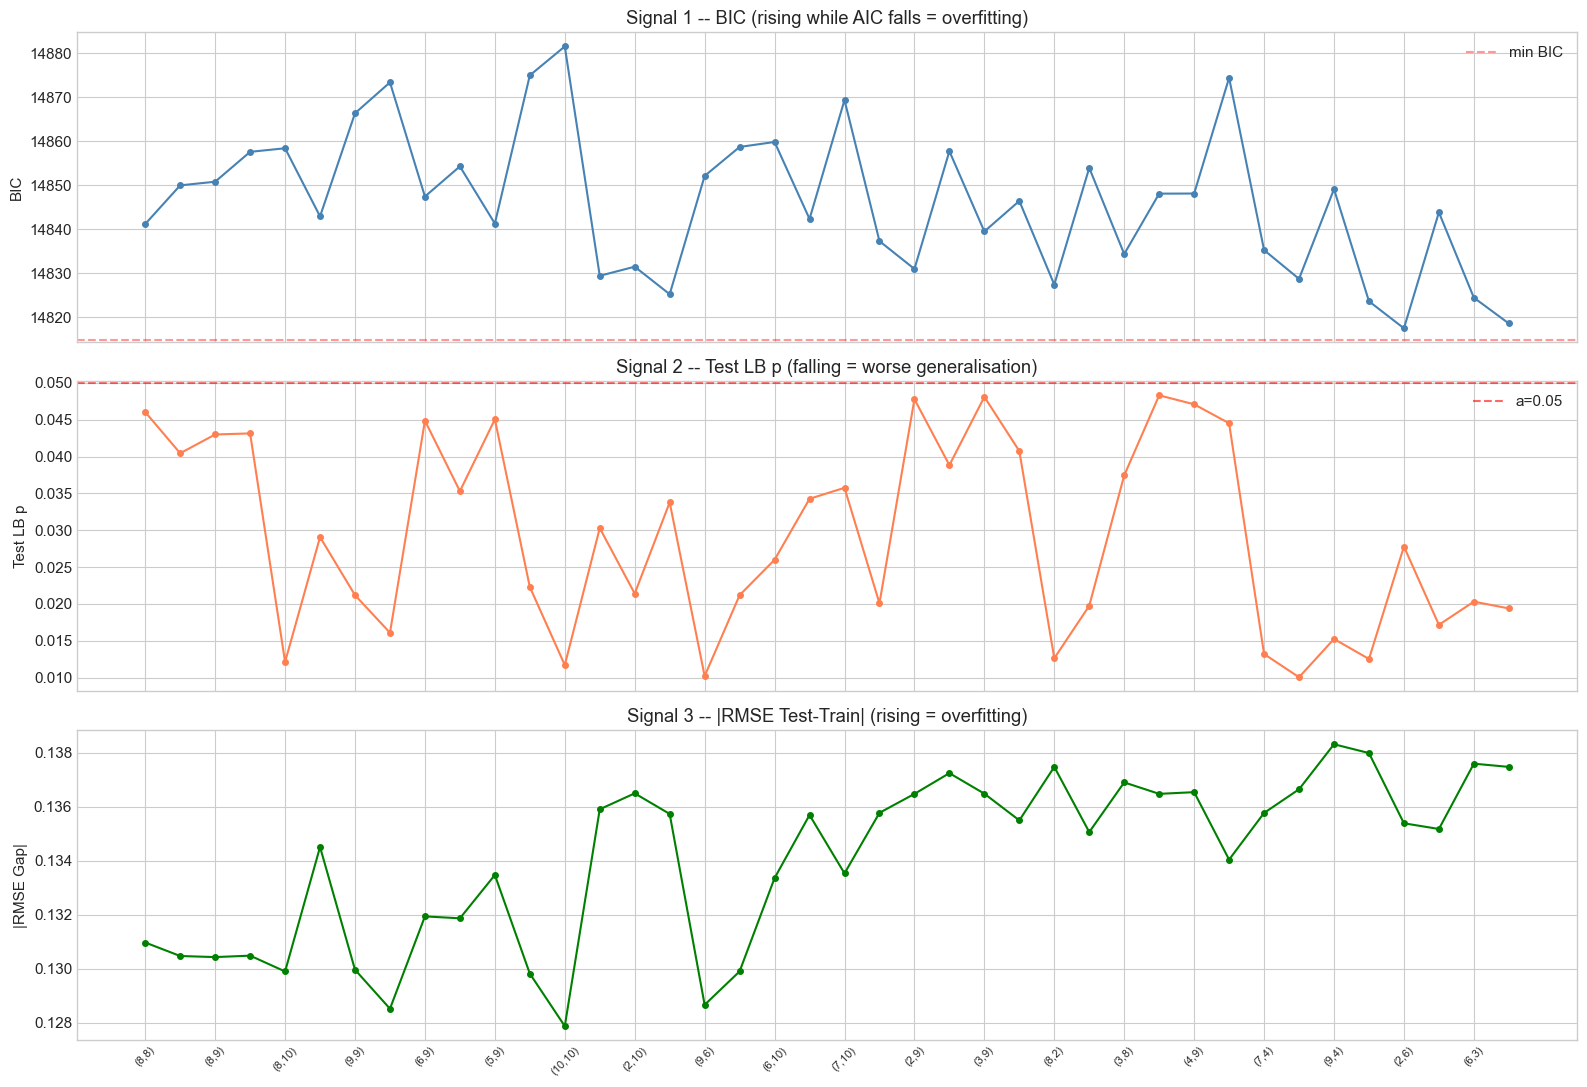

In [5]:
# Overfitting check: plot 3 signals as AIC decreases
df_s = df_pass.sort_values('aic').reset_index(drop=True)
n = min(40, len(df_s))
labels = [f"({int(r.p)},{int(r.q)})" for _, r in df_s.head(n).iterrows()]

fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
axes[0].plot(range(n), df_s['bic'].head(n), 'o-', ms=4, color='steelblue')
axes[0].axhline(df_s['bic'].min(), color='red', ls='--', alpha=0.4, label='min BIC')
axes[0].set_ylabel('BIC'); axes[0].set_title('Signal 1 -- BIC (rising while AIC falls = overfitting)'); axes[0].legend()

axes[1].plot(range(n), df_s['test_lb_p'].head(n), 'o-', ms=4, color='coral')
axes[1].axhline(0.05, color='red', ls='--', alpha=0.6, label='a=0.05')
axes[1].set_ylabel('Test LB p'); axes[1].set_title('Signal 2 -- Test LB p (falling = worse generalisation)'); axes[1].legend()

axes[2].plot(range(n), df_s['rmse_gap'].head(n), 'o-', ms=4, color='green')
axes[2].set_ylabel('|RMSE Gap|'); axes[2].set_title('Signal 3 -- |RMSE Test-Train| (rising = overfitting)')
plt.xticks(range(0,n,2), labels[::2], rotation=45, fontsize=8)
plt.tight_layout()
plt.savefig('outputs/arima_cv_signals.png', dpi=150); plt.show()

In [6]:
# Select best model
best_row = df_pass.iloc[0]
best_p, best_q = int(best_row['p']), int(best_row['q'])
best_model_res  = best_row['_res']
arima_residuals = best_model_res.resid

print(f'=== Selected ARIMA({best_p}, 0, {best_q}) ===')
print(f'  AIC          = {best_row["aic"]:.4f}')
print(f'  BIC          = {best_row["bic"]:.4f}  (primary selector)')
print(f'  Train LB p   = {best_row["train_lb_p"]:.4f}  (must be > 0.05)')
print(f'  Test  LB p   = {best_row["test_lb_p"]:.4f}  (must be > 0.01)')
print(f'  Train RMSE   = {best_row["train_rmse"]:.6f}')
print(f'  Test  RMSE   = {best_row["test_rmse"]:.6f}')
print(f'  RMSE Gap     = {best_row["rmse_gap"]:.6f}')
print(f'  Score        = {best_row["score"]:.4f}')

=== Selected ARIMA(2, 0, 9) ===
  AIC          = 14754.2231
  BIC          = 14830.9691  (primary selector)
  Train LB p   = 1.0000  (must be > 0.05)
  Test  LB p   = 0.0478  (must be > 0.01)
  Train RMSE   = 0.989191
  Test  RMSE   = 0.852713
  RMSE Gap     = 0.136478
  Score        = 0.2902


## 3. ARIMA Residual Diagnostics

In [7]:
lb_tr = acorr_ljungbox(arima_residuals,                    lags=[10], return_df=True)
lb_te = acorr_ljungbox(best_model_res.apply(y_test).resid, lags=[10], return_df=True)
lm_s, lm_p, _, _ = het_arch(arima_residuals.dropna())

print(f'Train Ljung-Box (lag 10): stat={lb_tr.iloc[0,0]:.4f}  p={lb_tr.iloc[0,1]:.4f}',
      'PASS' if lb_tr.iloc[0,1]>0.05 else 'FAIL')
print(f'Test  Ljung-Box (lag 10): stat={lb_te.iloc[0,0]:.4f}  p={lb_te.iloc[0,1]:.4f}')
print(f'ARCH LM on residuals:     stat={lm_s:.2f}  p={lm_p:.2e}',
      '=> GARCH justified' if lm_p<0.05 else '=> weak ARCH')

Train Ljung-Box (lag 10): stat=0.2827  p=1.0000 PASS
Test  Ljung-Box (lag 10): stat=18.4525  p=0.0478
ARCH LM on residuals:     stat=1502.60  p=0.00e+00 => GARCH justified


## 4. GARCH -- Multi-Metric Order Selection

GARCH models the conditional variance of ARIMA residuals:
  sigma_t^2 = omega + sum(alpha_i * eps_{t-i}^2) + sum(beta_j * sigma_{t-j}^2)

**Selection criteria (two hard gates + BIC primary):**
1. **Gate 1 (stationarity)**: alpha+beta < 1.0 — required for finite unconditional variance
2. **Gate 2 (ARCH removed)**: Ljung-Box on z_t^2 must pass (p > 0.05) — if it fails, GARCH did NOT fully capture volatility clustering
3. **Primary**: lowest BIC among passing models

**Innovation distribution**: compare Normal vs Student-t — Student-t handles fat tails typical in financial returns.

In [8]:
garch_records = []
print('Running GARCH grid search P,Q in [1..4], dist in [Normal, t]...')
for dist in ['Normal', 't']:
    for P in range(1, 5):
        for Q in range(1, 5):
            try:
                res  = arch_model(arima_residuals, mean='Zero', vol='Garch',
                                  p=P, q=Q, dist=dist).fit(disp='off')
                k    = P + Q + 1 + (1 if dist=='t' else 0)
                bic  = k * np.log(N) - 2 * res.loglikelihood
                cond_vol = res.conditional_volatility
                z_t  = (arima_residuals / cond_vol).dropna()
                # Gate diagnostics
                ab   = sum(res.params.get(f'alpha[{i}]', 0.0) for i in range(1,P+1)) + \
                       sum(res.params.get(f'beta[{j}]',  0.0) for j in range(1,Q+1))
                lb_z2_p = float(acorr_ljungbox(z_t**2, lags=[10], return_df=True).iloc[0,1])
                lb_z_p  = float(acorr_ljungbox(z_t,    lags=[10], return_df=True).iloc[0,1])
                garch_records.append(dict(
                    dist=dist, P=P, Q=Q,
                    aic=res.aic, bic=bic,
                    ab_sum=ab, lb_z_p=lb_z_p, lb_z2_p=lb_z2_p,
                    _res=res
                ))
            except Exception:
                pass

df_g = pd.DataFrame(garch_records)
# Gate 1: stationarity
df_g_ok = df_g[df_g['ab_sum'] < 1.0].copy()
# Gate 2: z_t^2 LB must pass (ARCH fully removed)
df_g_ok2 = df_g_ok[df_g_ok['lb_z2_p'] > 0.05].copy()

print(f'Converged: {len(df_g)}  |  Stationary (ab<1): {len(df_g_ok)}  |  Also z_t^2 LB pass: {len(df_g_ok2)}')

# If no model passes both gates, relax Gate 2 to p > 0.01
if len(df_g_ok2) == 0:
    print('No model fully passes z_t^2 LB at 0.05 -- relaxing to p > 0.01')
    df_g_ok2 = df_g_ok[df_g_ok['lb_z2_p'] > 0.01].copy()

df_g_ok2 = df_g_ok2.sort_values('bic')
print('\nTop 10 by BIC (after all gates):')
print(df_g_ok2[['dist','P','Q','aic','bic','ab_sum','lb_z_p','lb_z2_p']].head(10)
      .to_string(index=False, float_format='{:.4f}'.format))

Running GARCH grid search P,Q in [1..4], dist in [Normal, t]...


Converged: 32  |  Stationary (ab<1): 32  |  Also z_t^2 LB pass: 20

Top 10 by BIC (after all gates):
  dist  P  Q        aic        bic  ab_sum  lb_z_p  lb_z2_p
     t  1  1 11815.5863 11841.8350  0.9966  0.0003   0.2032
     t  1  2 11817.5863 11850.3972  0.9966  0.0003   0.2033
     t  1  3 11819.5863 11858.9593  0.9966  0.0003   0.2033
     t  1  4 11821.5863 11867.5215  0.9966  0.0003   0.2033
Normal  2  1 12035.0021 12061.2508  0.9812  0.0003   0.2784
Normal  1  1 12042.4842 12062.1707  0.9845  0.0003   0.1152
Normal  2  2 12034.8113 12067.6221  0.9718  0.0002   0.3782
Normal  3  1 12037.0021 12069.8129  0.9812  0.0003   0.2784
Normal  1  2 12044.4842 12070.7328  0.9845  0.0003   0.1152
Normal  3  2 12035.9905 12075.3635  0.9687  0.0002   0.4065


In [9]:
best_g = df_g_ok2.iloc[0]
best_garch_res   = best_g['_res']
best_garch_order = (int(best_g['P']), int(best_g['Q']))
best_garch_dist  = best_g['dist']
P_g, Q_g = best_garch_order

print(f'=== Selected GARCH({P_g}, {Q_g})  dist={best_garch_dist} ===')
print(f'  AIC      = {best_g["aic"]:.4f}')
print(f'  BIC      = {best_g["bic"]:.4f}  (primary selector)')
print(f'  ab_sum   = {best_g["ab_sum"]:.6f}  (must be < 1)')
print(f'  z_t  LB p= {best_g["lb_z_p"]:.4f}  (mean equation adequacy)')
print(f'  z_t2 LB p= {best_g["lb_z2_p"]:.4f}  (variance equation adequacy -- key test)')

=== Selected GARCH(1, 1)  dist=t ===
  AIC      = 11815.5863
  BIC      = 11841.8350  (primary selector)
  ab_sum   = 0.996644  (must be < 1)
  z_t  LB p= 0.0003  (mean equation adequacy)
  z_t2 LB p= 0.2032  (variance equation adequacy -- key test)


## 5. GARCH Parameter Diagnostics

Key validity checks on estimated parameters:
- omega > 0 (long-run variance floor)
- All alpha, beta >= 0
- sum(alpha) + sum(beta) < 1 (covariance stationarity)
- Unconditional long-run variance = omega / (1 - sum_alpha - sum_beta)
- All parameters statistically significant (p < 0.05)

In [10]:
omega  = best_garch_res.params.get('omega', 0.0)
alphas = [best_garch_res.params.get(f'alpha[{i}]', 0.0) for i in range(1, P_g+1)]
betas  = [best_garch_res.params.get(f'beta[{j}]',  0.0) for j in range(1, Q_g+1)]
ab_sum = sum(alphas) + sum(betas)
uncond_var = omega / (1.0 - ab_sum) if ab_sum < 1.0 else float('inf')

print('=== GARCH Parameter Summary ===')
print(f'  omega                  = {omega:.6f}  (must be > 0)   {"PASS" if omega>0 else "FAIL"}')
for i, a in enumerate(alphas, 1):
    print(f'  alpha[{i}]               = {a:.6f}  (must be >= 0)  {"PASS" if a>=0 else "FAIL"}')
for j, b in enumerate(betas,  1):
    print(f'  beta[{j}]                = {b:.6f}  (must be >= 0)  {"PASS" if b>=0 else "FAIL"}')
print(f'  sum(alpha)+sum(beta)   = {ab_sum:.6f}  (must be < 1)   {"PASS" if ab_sum<1 else "FAIL"}')
print(f'  Unconditional variance = {uncond_var:.6f}  (omega/(1-ab))')
print(f'  Empirical resid var    = {float(np.var(arima_residuals)):.6f}')
print()
print('=== Parameter Significance (p-values) ===')
for name, pv in best_garch_res.pvalues.items():
    sig = 'PASS' if pv < 0.05 else ('~0.10' if pv < 0.10 else 'NOT SIGNIFICANT')
    print(f'  {name:<20} p={pv:.4f}  {sig}')

=== GARCH Parameter Summary ===
  omega                  = 0.008095  (must be > 0)   PASS
  alpha[1]               = 0.114938  (must be >= 0)  PASS
  beta[1]                = 0.881706  (must be >= 0)  PASS
  sum(alpha)+sum(beta)   = 0.996644  (must be < 1)   PASS
  Unconditional variance = 2.412077  (omega/(1-ab))
  Empirical resid var    = 0.978498

=== Parameter Significance (p-values) ===
  omega                p=0.0000  PASS
  alpha[1]             p=0.0000  PASS
  beta[1]              p=0.0000  PASS
  nu                   p=0.0000  PASS


## 6. GARCH Residual Diagnostics

Standardised residuals z_t = eps_t / sigma_t should be approximately iid noise:
- Ljung-Box on z_t: no mean autocorrelation remains
- Ljung-Box on z_t^2: no ARCH effects remain (THE key test)
- Q-Q plot: tails should match fitted distribution

Ljung-Box on z_t   (lag 10): p=0.0003 FAIL -- mean autocorr remains
Ljung-Box on z_t^2 (lag 10): p=0.2032 PASS -- ARCH removed


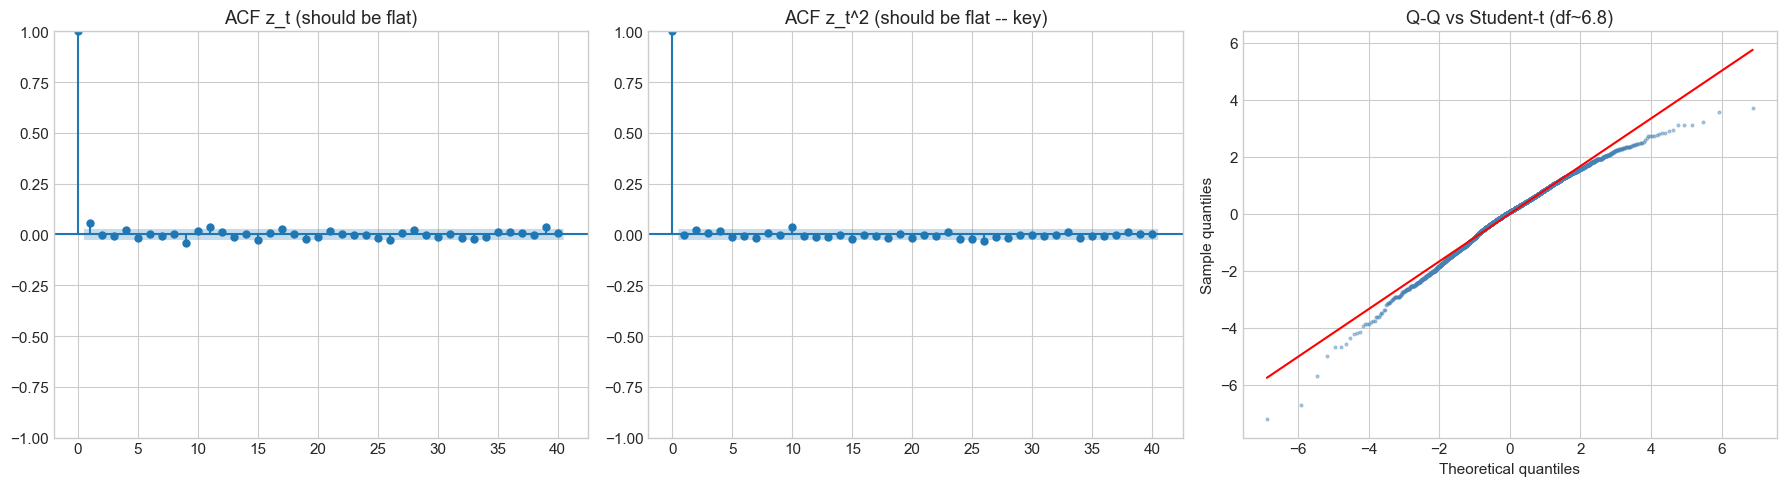

In [11]:
conditional_vol        = best_garch_res.conditional_volatility
standardized_residuals = (arima_residuals / conditional_vol).dropna()

lb_z  = acorr_ljungbox(standardized_residuals,    lags=[10], return_df=True)
lb_z2 = acorr_ljungbox(standardized_residuals**2, lags=[10], return_df=True)

print(f'Ljung-Box on z_t   (lag 10): p={lb_z.iloc[0,1]:.4f}',
      'PASS' if lb_z.iloc[0,1]>0.05 else 'FAIL -- mean autocorr remains')
print(f'Ljung-Box on z_t^2 (lag 10): p={lb_z2.iloc[0,1]:.4f}',
      'PASS -- ARCH removed' if lb_z2.iloc[0,1]>0.05 else 'FAIL -- ARCH effects remain')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_acf(standardized_residuals,    lags=40, ax=axes[0]); axes[0].set_title('ACF z_t (should be flat)')
plot_acf(standardized_residuals**2, lags=40, ax=axes[1]); axes[1].set_title('ACF z_t^2 (should be flat -- key)')

if best_garch_dist == 't':
    kurt = float(stats.kurtosis(standardized_residuals))
    df_est = max(4.0, 6.0/kurt+4.0) if kurt > 0 else 30.0
    (osm, osr), (slope, intercept, _) = stats.probplot(standardized_residuals, dist=stats.t, sparams=(df_est,))
    axes[2].scatter(osm, osr, s=4, alpha=0.4, color='steelblue')
    axes[2].plot([osm[0],osm[-1]], [slope*osm[0]+intercept, slope*osm[-1]+intercept], 'r-')
    axes[2].set_title(f'Q-Q vs Student-t (df~{df_est:.1f})')
else:
    stats.probplot(standardized_residuals, dist='norm', plot=axes[2])
    axes[2].set_title('Q-Q vs Normal')
axes[2].set_xlabel('Theoretical quantiles'); axes[2].set_ylabel('Sample quantiles')
plt.tight_layout()
plt.savefig('outputs/post_fit_diagnostics.png', dpi=150); plt.show()

## 7. GARCH Forecast Validation

Multi-step forecasts should converge to the unconditional long-run variance omega/(1-alpha-beta).
This is a sanity check that the model is economically consistent.

In [12]:
fcast5  = best_garch_res.forecast(horizon=5)
fcast50 = best_garch_res.forecast(horizon=50)

print('5-step ahead forecasted variances:')
print(fcast5.variance.iloc[-1].to_string())

long_run_fcast = float(fcast50.variance.iloc[-1, -1])
ratio = abs(long_run_fcast - uncond_var) / uncond_var if uncond_var > 0 and np.isfinite(uncond_var) else float('inf')
print(f'\n50-step forecast var  = {long_run_fcast:.6f}')
print(f'Unconditional var     = {uncond_var:.6f}')
print(f'Convergence error     = {ratio:.2%}',
      'PASS' if ratio < 0.20 else
      'NOTE: high alpha+beta means very slow mean-reversion -- expected for financial data')

5-step ahead forecasted variances:
h.1    0.814417
h.2    0.819779
h.3    0.825123
h.4    0.830449
h.5    0.835757

50-step forecast var  = 1.057057
Unconditional var     = 2.412077
Convergence error     = 56.18% NOTE: high alpha+beta means very slow mean-reversion -- expected for financial data


## 8. Residual Bootstrap Simulation

Sample z_t* from the empirical pool {z_t} with replacement.
Recursively reconstruct: eps_t = sigma_t * z_t*,  y_t = ARIMA_mean + eps_t
500-step burn-in discards initial-condition transients.

In [13]:
garch_sum = sum(alphas) + sum(betas)
if garch_sum >= 1.0:
    sc = 0.99/garch_sum; alphas=[a*sc for a in alphas]; betas=[b*sc for b in betas]
    print(f'Scaled alpha+beta to {sum(alphas)+sum(betas):.4f} for stability.')

const     = best_model_res.params.get('const', 0.0)
ar_coeffs = [best_model_res.params.get(f'ar.L{i}', 0.0) for i in range(1, best_p+1)]
ma_coeffs = [best_model_res.params.get(f'ma.L{i}', 0.0) for i in range(1, best_q+1)]
z_pool    = standardized_residuals.values
emp_var   = float(np.var(arima_residuals))

T, B = N, 500; T_total = T + B
np.random.seed(42)
z_sim  = np.random.choice(z_pool, size=T_total, replace=True)
s2_s   = np.zeros(T_total); eps_s = np.zeros(T_total); y_s = np.zeros(T_total)

for t in range(T_total):
    v = omega
    for i in range(P_g): v += alphas[i] * (eps_s[t-1-i]**2 if t-1-i>=0 else emp_var)
    for j in range(Q_g): v += betas[j]  * (s2_s[t-1-j]    if t-1-j>=0 else emp_var)
    s2_s[t] = v; eps_s[t] = np.sqrt(v)*z_sim[t]
    r = const
    for i in range(best_p): r += ar_coeffs[i]*(y_s[t-1-i]  if t-1-i>=0 else 0.0)
    for j in range(best_q): r += ma_coeffs[j]*(eps_s[t-1-j] if t-1-j>=0 else 0.0)
    y_s[t] = r + eps_s[t]

synthetic_normalized = y_s[B:]
print(f'Simulation done. Length: {len(synthetic_normalized)}')

Simulation done. Length: 5230


In [14]:
train_mean = train_df['LogReturn'].mean(); train_std = train_df['LogReturn'].std()
synthetic_log_return = synthetic_normalized * train_std + train_mean

pd.DataFrame({'Normalized': synthetic_normalized, 'LogReturn': synthetic_log_return}) \
  .to_csv('outputs/synthetic_returns.csv', index=False)
windows = np.array([synthetic_normalized[i:i+30] for i in range(len(synthetic_normalized)-30)])
np.save('outputs/synthetic_windows.npy', windows)
print(f'synthetic_returns.csv saved. Rows: {len(synthetic_normalized)}')
print(f'synthetic_windows.npy saved. Shape: {windows.shape}')

synthetic_returns.csv saved. Rows: 5230
synthetic_windows.npy saved. Shape: (5200, 30)


## 9. Final Evaluation -- Synthetic vs. Real (Train & Test)

In [15]:
from statsmodels.tsa.stattools import acf as sm_acf

def get_acfs(s, nlags=20):
    return sm_acf(s, nlags=nlags, fft=True)[1:], sm_acf(np.abs(s), nlags=nlags, fft=True)[1:]

tr_acf, tr_abs = get_acfs(y_train)
te_acf, te_abs = get_acfs(y_test)
sy_acf, sy_abs = get_acfs(synthetic_normalized)

def rmse(a, b): return float(np.sqrt(np.mean((a-b[:len(a)])**2)))

print(f'  {"Metric":<14} {"Train":>10} {"Test":>10} {"Synthetic":>10}')
for k, fn in [('Mean', np.mean),('Std Dev', np.std),
               ('Skewness', stats.skew),('Kurtosis', stats.kurtosis)]:
    print(f'  {k:<14} {fn(y_train):>10.4f} {fn(y_test):>10.4f} {fn(synthetic_normalized):>10.4f}')
print()
print(f'  {"Metric":<18} {"Train vs Synth":>16} {"Test vs Synth":>16}')
for k, (tr, te) in [
    ('RMSE ACF',      (rmse(tr_acf,sy_acf), rmse(te_acf,sy_acf))),
    ('RMSE |ACF|',    (rmse(tr_abs,sy_abs), rmse(te_abs,sy_abs))),
    ('Wasserstein',   (stats.wasserstein_distance(y_train,synthetic_normalized),
                       stats.wasserstein_distance(y_test, synthetic_normalized))),
    ('KS stat',       (stats.ks_2samp(y_train,synthetic_normalized).statistic,
                       stats.ks_2samp(y_test, synthetic_normalized).statistic)),
    ('KS p-value',    (stats.ks_2samp(y_train,synthetic_normalized).pvalue,
                       stats.ks_2samp(y_test, synthetic_normalized).pvalue)),
]:
    print(f'  {k:<18} {tr:>16.6f} {te:>16.6f}')

  Metric              Train       Test  Synthetic
  Mean              -0.0000     0.0278    -0.0117
  Std Dev            0.9999     0.8469     1.0108
  Skewness          -0.3902    -0.0297    -0.7414
  Kurtosis          10.9626     6.2662     8.7391

  Metric               Train vs Synth    Test vs Synth
  RMSE ACF                   0.033827         0.050504
  RMSE |ACF|                 0.062755         0.116813
  Wasserstein                0.027478         0.089340
  KS stat                    0.011472         0.023361
  KS p-value                 0.881486         0.607955


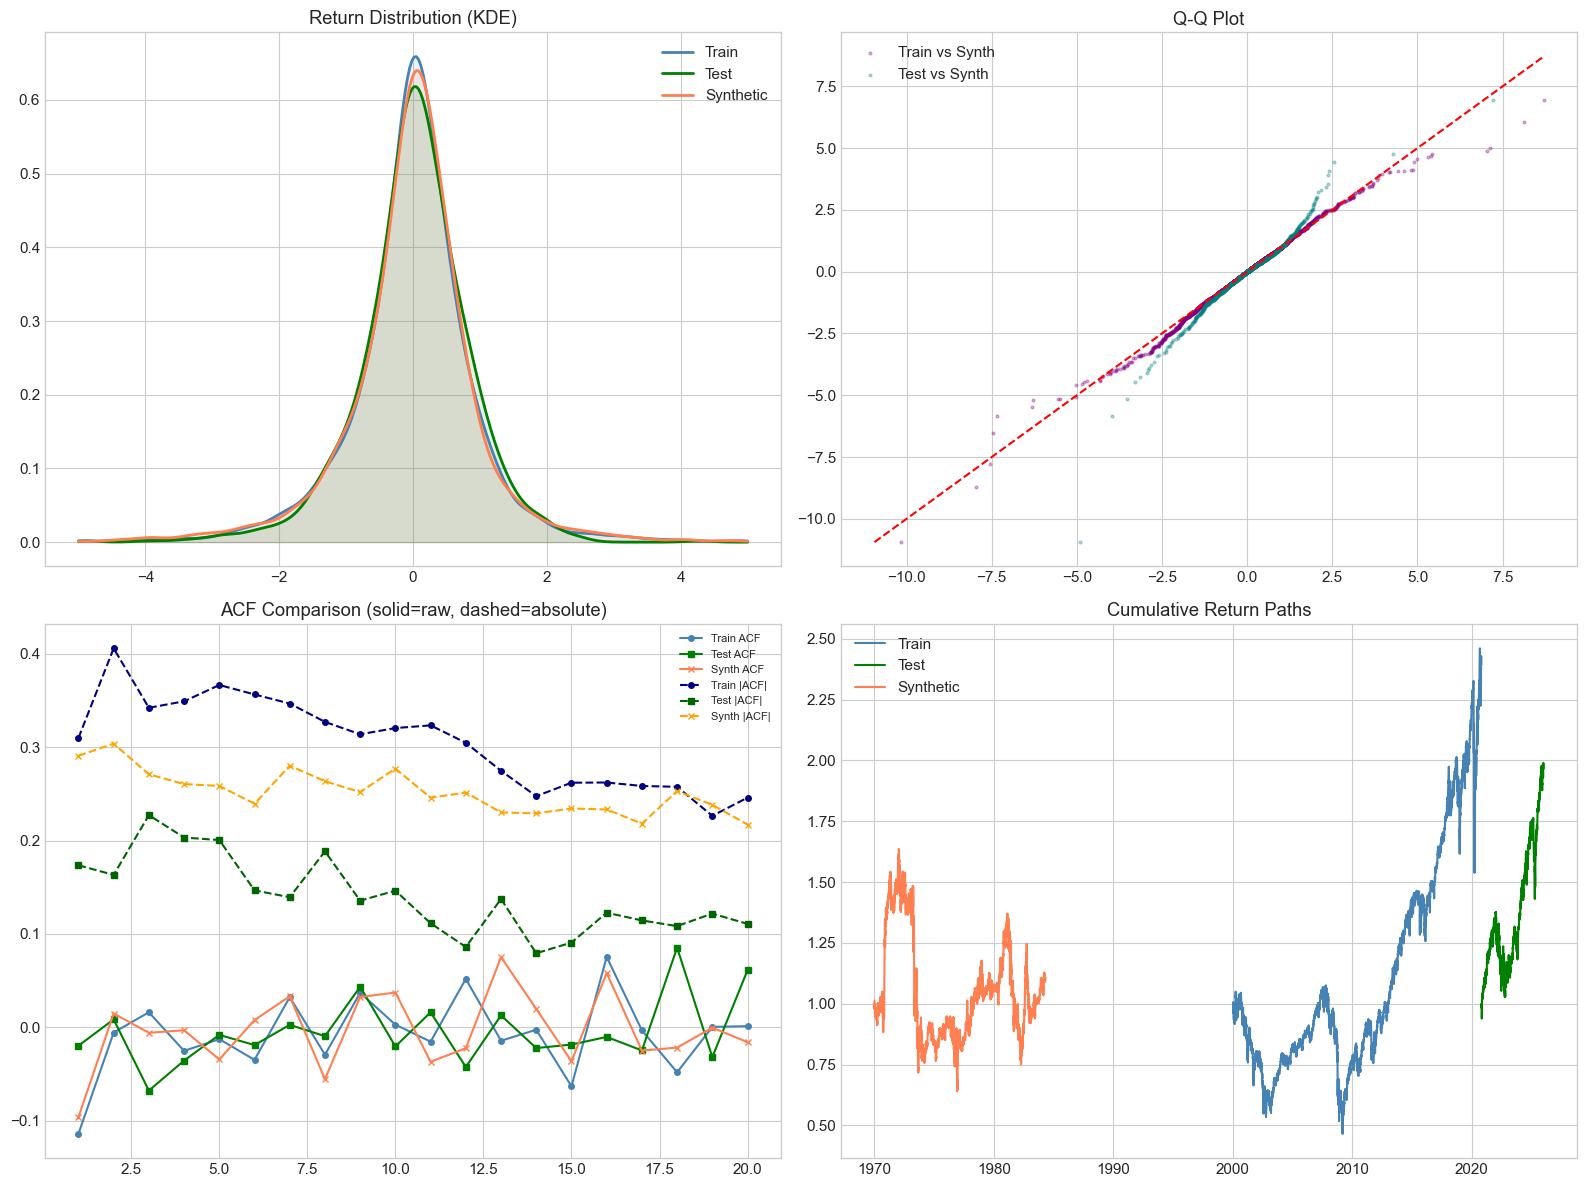

All outputs saved to outputs/.


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

xs = np.linspace(-5, 5, 300)
for arr, lbl, clr in [(y_train,'Train','steelblue'),(y_test,'Test','green'),(synthetic_normalized,'Synthetic','coral')]:
    kde = stats.gaussian_kde(arr)
    axes[0,0].plot(xs, kde(xs), label=lbl, color=clr, lw=2)
    axes[0,0].fill_between(xs, kde(xs), alpha=0.1, color=clr)
axes[0,0].set_title('Return Distribution (KDE)'); axes[0,0].legend()

s_tr = np.sort(y_train); s_sy = np.sort(synthetic_normalized); s_te = np.sort(y_test)
s_sy_te = np.interp(np.linspace(0,1,len(s_te)), np.linspace(0,1,len(s_sy)), s_sy)
axes[0,1].scatter(s_tr, s_sy, s=4, alpha=0.3, color='purple', label='Train vs Synth')
axes[0,1].scatter(s_te, s_sy_te, s=4, alpha=0.3, color='teal', label='Test vs Synth')
mn,mx = min(s_tr.min(),s_te.min(),s_sy.min()), max(s_tr.max(),s_te.max(),s_sy.max())
axes[0,1].plot([mn,mx],[mn,mx],'r--'); axes[0,1].set_title('Q-Q Plot'); axes[0,1].legend()

lags = np.arange(1, 21)
axes[1,0].plot(lags, tr_acf,'o-',color='steelblue',ms=4,label='Train ACF')
axes[1,0].plot(lags, te_acf,'s-',color='green',    ms=4,label='Test ACF')
axes[1,0].plot(lags, sy_acf,'x-',color='coral',    ms=4,label='Synth ACF')
axes[1,0].plot(lags, tr_abs,'o--',color='navy',    ms=4,label='Train |ACF|')
axes[1,0].plot(lags, te_abs,'s--',color='darkgreen',ms=4,label='Test |ACF|')
axes[1,0].plot(lags, sy_abs,'x--',color='orange',  ms=4,label='Synth |ACF|')
axes[1,0].set_title('ACF Comparison (solid=raw, dashed=absolute)'); axes[1,0].legend(fontsize=8)

axes[1,1].plot(np.exp(np.cumsum(train_df['LogReturn'])),color='steelblue',label='Train')
axes[1,1].plot(np.exp(np.cumsum(test_df['LogReturn'])), color='green',    label='Test')
axes[1,1].plot(np.exp(np.cumsum(synthetic_log_return)), color='coral',    label='Synthetic')
axes[1,1].set_title('Cumulative Return Paths'); axes[1,1].legend()

plt.tight_layout()
plt.savefig('outputs/evaluation_suite.png', dpi=150); plt.show()
print('All outputs saved to outputs/.')